--- SUCCESS! File found and loaded perfectly! ---

--- TASK 2: EXPLORATORY DATA ANALYSIS (EDA) ---
Overall Customer Churn Rate: 26.54%



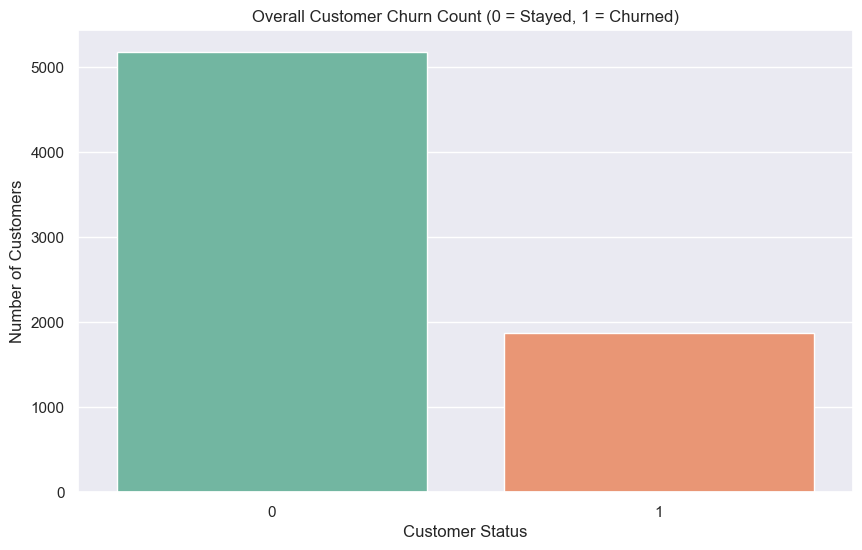

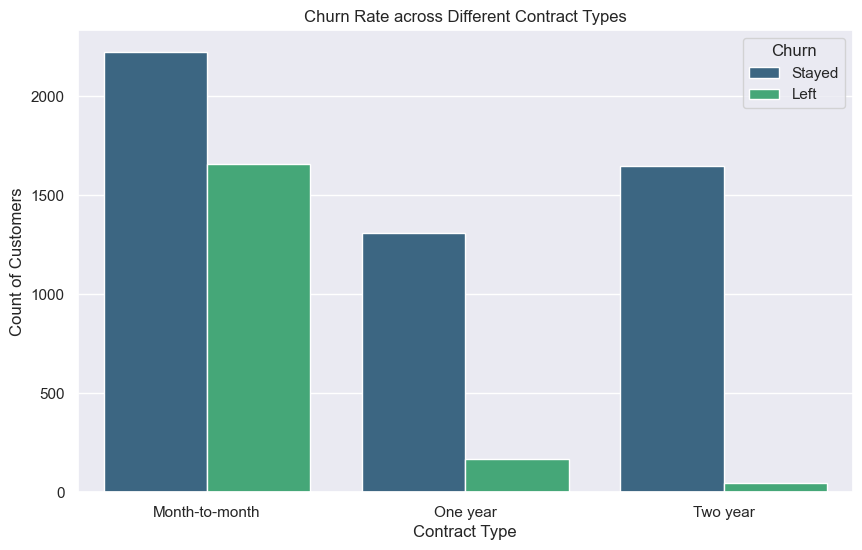

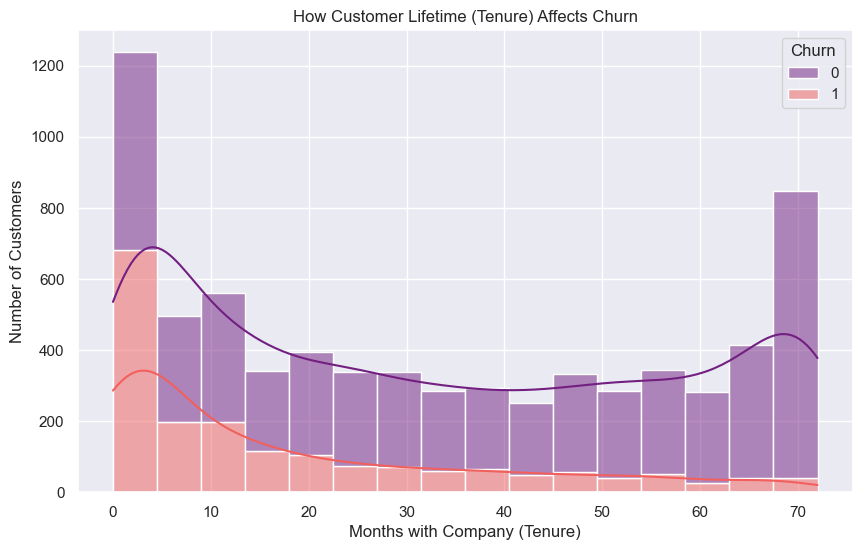

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

file_name = "Telco_Customer_Churn_Dataset  (3).csv"

try:
    df = pd.read_csv(file_name)
    print("--- SUCCESS! File found and loaded perfectly! ---")
except Exception as e:
    try:
        desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
        df = pd.read_csv(os.path.join(desktop_path, file_name))
        print("--- SUCCESS! File found on Desktop and loaded! ---")
    except Exception as e2:
        print("Still couldn't find the file. Make sure the file name matches exactly!")

df['Churn'] = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("\n--- TASK 2: EXPLORATORY DATA ANALYSIS (EDA) ---")

churn_column_name = 'Churn'
churn_rate = df[churn_column_name].mean() * 100
print(f"Overall Customer Churn Rate: {churn_rate:.2f}%\n")

plt.figure()
sns.countplot(x=churn_column_name, data=df, palette='Set2', hue=churn_column_name, legend=False)
plt.title('Overall Customer Churn Count (0 = Stayed, 1 = Churned)')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.show()

contract_col = [c for c in df.columns if 'contract' in c.lower()]
if contract_col:
    plt.figure()
    sns.countplot(x=contract_col[0], hue=churn_column_name, data=df, palette='viridis')
    plt.title('Churn Rate across Different Contract Types')
    plt.xlabel('Contract Type')
    plt.ylabel('Count of Customers')
    plt.legend(title='Churn', labels=['Stayed', 'Left'])
    plt.show()
else:
    print("Note: 'Contract' column not found, skipping contract chart.")

tenure_col = [c for c in df.columns if 'tenure' in c.lower()]
if tenure_col:
    plt.figure()
    sns.histplot(data=df, x=tenure_col[0], hue=churn_column_name, kde=True, multiple="stack", palette='magma')
    plt.title('How Customer Lifetime (Tenure) Affects Churn')
    plt.xlabel('Months with Company (Tenure)')
    plt.ylabel('Number of Customers')
    plt.show()
else:
    print("Note: 'Tenure' column not found, skipping tenure chart.")